# Task 3: Dataset Preparation and Preprocessing for Deep Learning

## Dataset: CIFAR-10

**Objective:** Prepare and preprocess the CIFAR-10 image dataset for deep learning by performing exploratory data analysis, data-quality checks, normalization, augmentation, visualization, and train-validation-test splitting.

### Tools and Libraries
- Python
- TensorFlow / Keras
- NumPy
- Pandas
- Matplotlib
- Seaborn

### Dataset
CIFAR-10 contains 60,000 color images of size 32×32 pixels belonging to 10 classes.


In [1]:
# 1. Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
np.random.seed(42)
tf.random.set_seed(42)


TensorFlow version: 2.20.0


## 2. Load the CIFAR-10 Dataset

In [2]:
# CIFAR-10 provides predefined training and test sets.
# We will create a validation set from the training data.

(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Original training images:", x_train_full.shape)
print("Original training labels:", y_train_full.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2299s 13us/step
Original training images: (50000, 32, 32, 3)
Original training labels: (50000, 1)
Test images: (10000, 32, 32, 3)
Test labels: (10000, 1)


## 3. Dataset Overview

In [3]:
# Basic dataset information

print("Total images:", len(x_train_full) + len(x_test))
print("Image shape:", x_train_full.shape[1:])
print("Number of classes:", len(class_names))
print("Data type:", x_train_full.dtype)
print("Minimum pixel value:", x_train_full.min())
print("Maximum pixel value:", x_train_full.max())

print("\nClass names:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")


Total images: 60000
Image shape: (32, 32, 3)
Number of classes: 10
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255

Class names:
0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck


## 4. Exploratory Data Analysis (EDA)

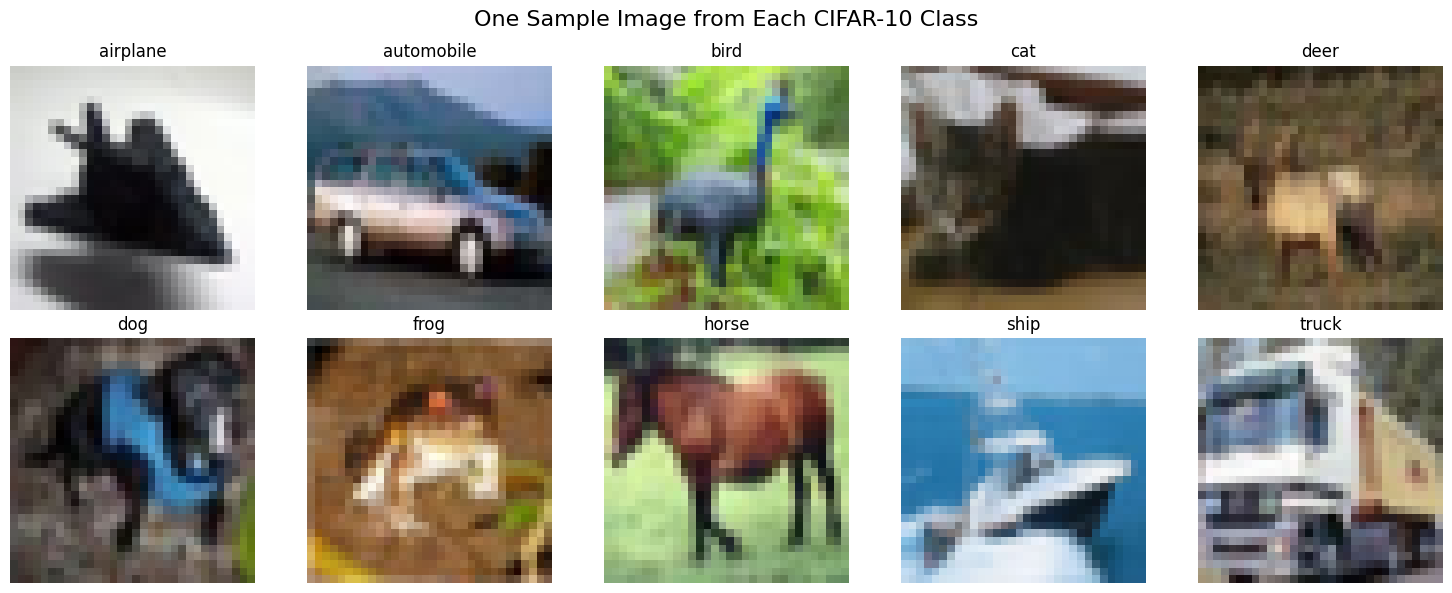

In [4]:
# Display sample images from each class

plt.figure(figsize=(15, 6))

for class_id in range(10):
    index = np.where(y_train_full.flatten() == class_id)[0][0]
    plt.subplot(2, 5, class_id + 1)
    plt.imshow(x_train_full[index])
    plt.title(class_names[class_id])
    plt.axis("off")

plt.suptitle("One Sample Image from Each CIFAR-10 Class", fontsize=16)
plt.tight_layout()
plt.show()


,Class,Number of Images
0,airplane,5000
1,automobile,5000
2,bird,5000
3,cat,5000
4,deer,5000
5,dog,5000
6,frog,5000
7,horse,5000
8,ship,5000
9,truck,5000


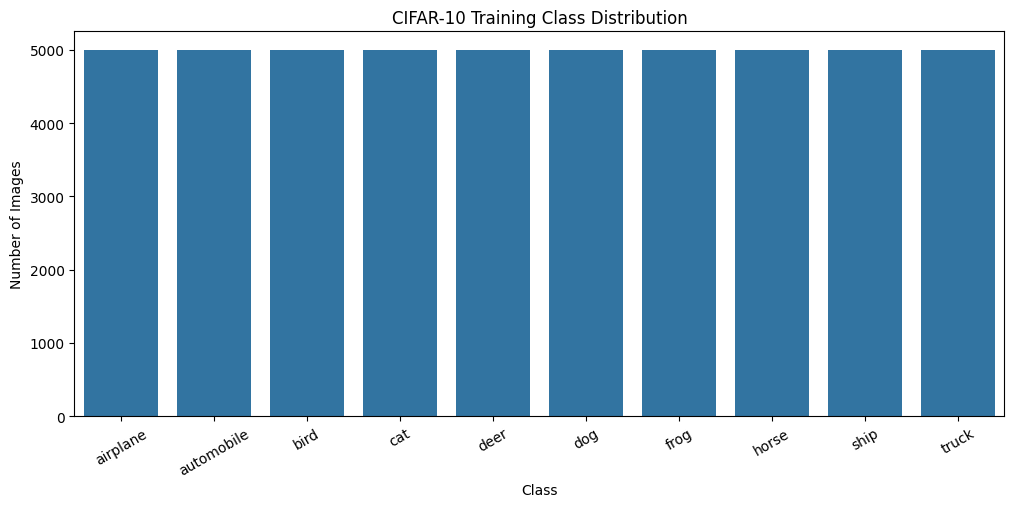

In [5]:
# Class distribution

class_counts = pd.Series(
    y_train_full.flatten()
).value_counts().sort_index()

distribution_df = pd.DataFrame({
    "Class": class_names,
    "Number of Images": class_counts.values
})

display(distribution_df)

plt.figure(figsize=(12, 5))
sns.barplot(data=distribution_df, x="Class", y="Number of Images")
plt.title("CIFAR-10 Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.show()


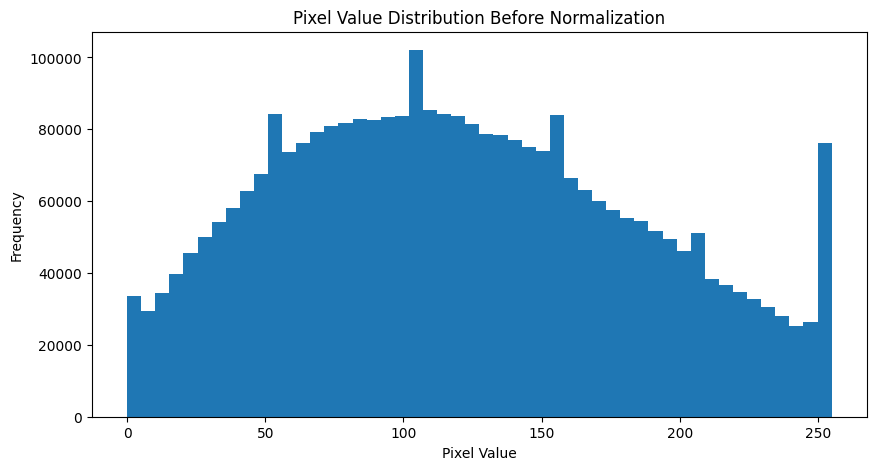

In [6]:
# Pixel value distribution using a representative sample

sample_pixels = x_train_full[:1000].reshape(-1)

plt.figure(figsize=(10, 5))
plt.hist(sample_pixels, bins=50)
plt.title("Pixel Value Distribution Before Normalization")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()


## 5. Data Quality Checks

The CIFAR-10 arrays are checked for:
- Missing values
- Invalid pixel values
- Invalid labels
- Unexpected image dimensions
- Duplicate images within the loaded training array

A duplicate check is performed on a manageable subset to avoid excessive memory use.


In [7]:
# Missing-value checks

print("Missing values in training images:", np.isnan(x_train_full).sum())
print("Missing values in test images:", np.isnan(x_test).sum())
print("Missing values in training labels:", np.isnan(y_train_full).sum())
print("Missing values in test labels:", np.isnan(y_test).sum())

# Label validity
print("\nUnique training labels:", np.unique(y_train_full))
print("Unique test labels:", np.unique(y_test))

# Pixel range validity
print("\nTraining pixel range:", x_train_full.min(), "to", x_train_full.max())
print("Test pixel range:", x_test.min(), "to", x_test.max())

# Shape checks
print("\nTraining image shape valid:", x_train_full.shape[1:] == (32, 32, 3))
print("Test image shape valid:", x_test.shape[1:] == (32, 32, 3))


Missing values in training images: 0
Missing values in test images: 0
Missing values in training labels: 0
Missing values in test labels: 0

Unique training labels: [0 1 2 3 4 5 6 7 8 9]
Unique test labels: [0 1 2 3 4 5 6 7 8 9]

Training pixel range: 0 to 255
Test pixel range: 0 to 255

Training image shape valid: True
Test image shape valid: True


In [8]:
# Duplicate check on a subset of training images
# (Exact duplicate images are not expected in normal CIFAR-10 loading.)

subset = x_train_full[:10000]
flat_subset = subset.reshape(len(subset), -1)
unique_count = np.unique(flat_subset, axis=0).shape[0]

print("Images checked:", len(subset))
print("Unique images:", unique_count)
print("Duplicate images in checked subset:", len(subset) - unique_count)


Images checked: 10000
Unique images: 10000
Duplicate images in checked subset: 0


## 6. Train-Validation-Test Split

In [9]:
# Create a validation set from the original training set.
# 45,000 training images, 5,000 validation images, 10,000 test images.

validation_size = 5000

x_val = x_train_full[-validation_size:]
y_val = y_train_full[-validation_size:]

x_train = x_train_full[:-validation_size]
y_train = y_train_full[:-validation_size]

print("Training set:", x_train.shape, y_train.shape)
print("Validation set:", x_val.shape, y_val.shape)
print("Test set:", x_test.shape, y_test.shape)


Training set: (45000, 32, 32, 3) (45000, 1)
Validation set: (5000, 32, 32, 3) (5000, 1)
Test set: (10000, 32, 32, 3) (10000, 1)


## 7. Image Preprocessing – Normalization

In [10]:
# Convert pixel values from [0, 255] to [0, 1]

x_train_norm = x_train.astype("float32") / 255.0
x_val_norm = x_val.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

print("Training pixel range after normalization:",
      x_train_norm.min(), "to", x_train_norm.max())
print("Data type:", x_train_norm.dtype)


Training pixel range after normalization: 0.0 to 1.0
Data type: float32


/tmp/ipykernel_1054/202853574.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


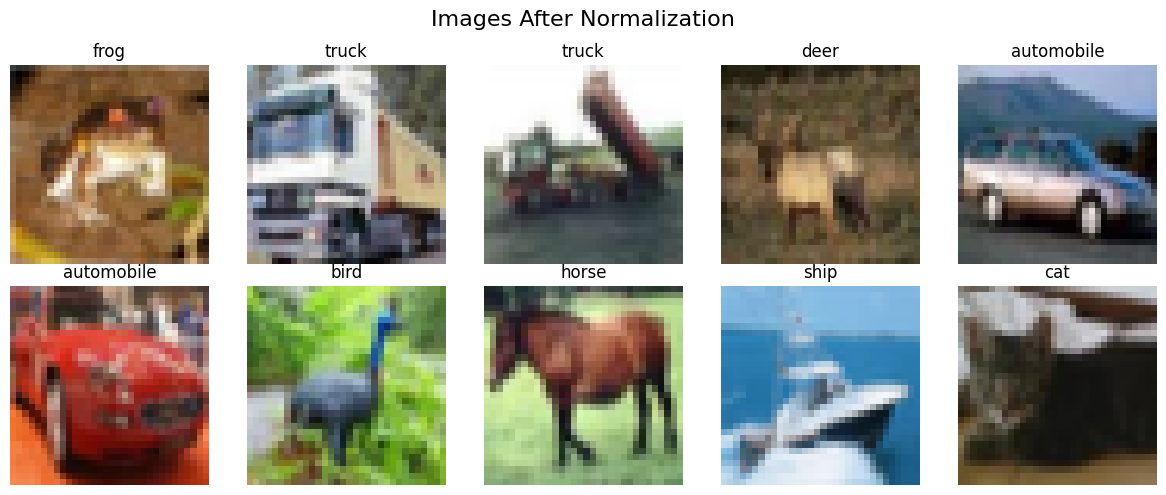

In [11]:
# Visualize normalized images

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_norm[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis("off")

plt.suptitle("Images After Normalization", fontsize=16)
plt.tight_layout()
plt.show()


## 8. Image Augmentation

In [12]:
# Data augmentation pipeline
# Augmentation is applied only to training images.

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
], name="data_augmentation")

data_augmentation.summary()


Model: "data_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ ?                      │   0 (unbuilt) │
│ (RandomTranslation)             │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

/tmp/ipykernel_1054/214367938.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"Augmented Versions of: {class_names[int(y_train[0])]}",


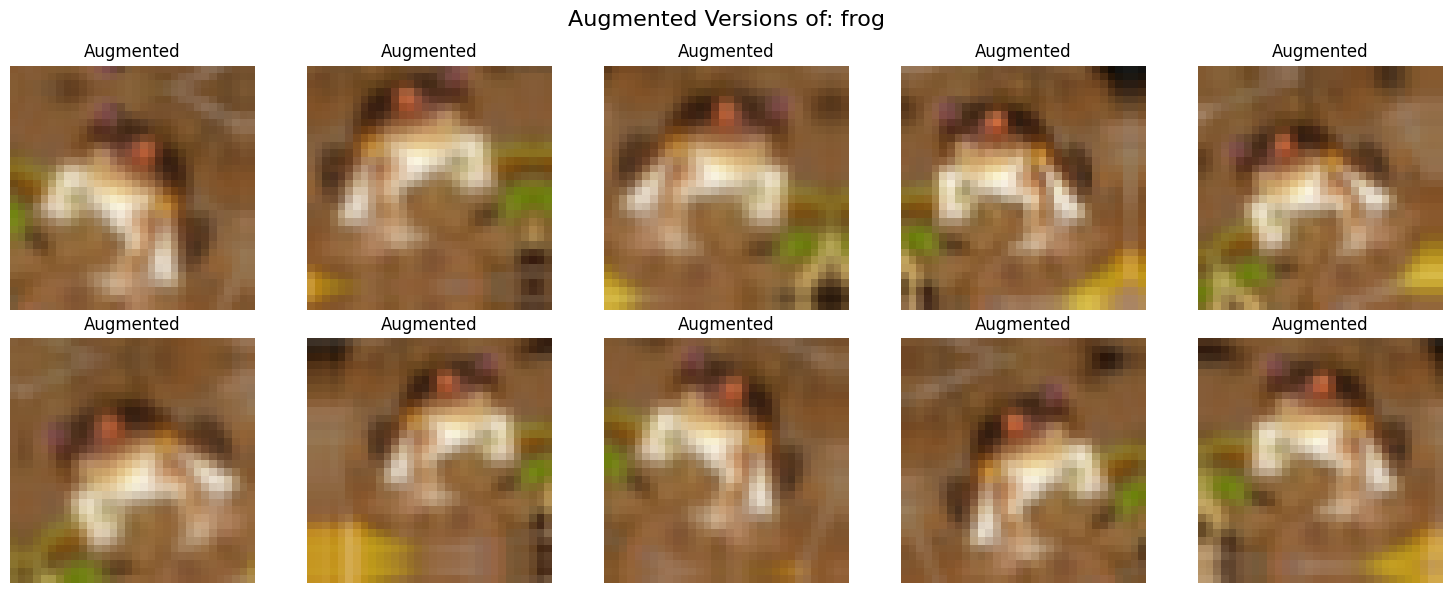

In [13]:
# Visualize original and augmented images

sample_image = tf.expand_dims(x_train_norm[0], axis=0)

plt.figure(figsize=(15, 6))

for i in range(10):
    augmented_image = data_augmentation(sample_image, training=True)[0]

    plt.subplot(2, 5, i + 1)
    plt.imshow(tf.clip_by_value(augmented_image, 0, 1))
    plt.title("Augmented")
    plt.axis("off")

plt.suptitle(
    f"Augmented Versions of: {class_names[int(y_train[0])]}",
    fontsize=16
)
plt.tight_layout()
plt.show()


## 9. Prepare TensorFlow Datasets

In [14]:
# Convert arrays into efficient tf.data.Dataset pipelines

BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((x_train_norm, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((x_val_norm, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((x_test_norm, y_test))

# Shuffle only the training set.
train_ds = train_ds.shuffle(10000, seed=42).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("TensorFlow datasets created successfully.")


TensorFlow datasets created successfully.


## 10. Verify the Preprocessed Dataset

In [15]:
# Inspect one batch

images_batch, labels_batch = next(iter(train_ds))

print("Batch image shape:", images_batch.shape)
print("Batch label shape:", labels_batch.shape)
print("Batch pixel range:", tf.reduce_min(images_batch).numpy(),
      "to", tf.reduce_max(images_batch).numpy())
print("Batch image dtype:", images_batch.dtype)


Batch image shape: (64, 32, 32, 3)
Batch label shape: (64, 1)
Batch pixel range: 0.0 to 1.0
Batch image dtype: <dtype: 'float32'>


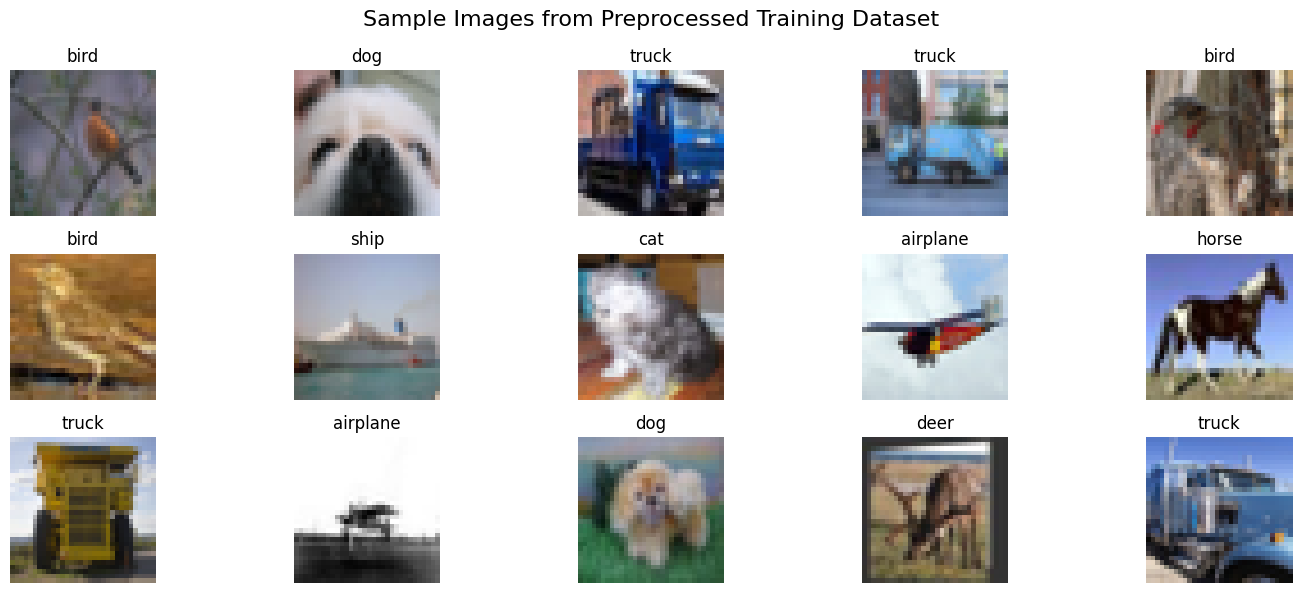

In [16]:
# Final visualization of a training batch

plt.figure(figsize=(15, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(images_batch[i])
    plt.title(class_names[int(labels_batch[i])])
    plt.axis("off")

plt.suptitle("Sample Images from Preprocessed Training Dataset", fontsize=16)
plt.tight_layout()
plt.show()


## 11. Preprocessing Summary

| Step | Operation |
|---|---|
| Dataset loading | CIFAR-10 loaded using Keras |
| EDA | Image samples, dimensions, class distribution and pixel distribution |
| Data quality | Missing values, labels, dimensions, pixel ranges and duplicates checked |
| Train split | 45,000 images |
| Validation split | 5,000 images |
| Test split | 10,000 images |
| Normalization | Pixel values scaled from 0–255 to 0–1 |
| Augmentation | Horizontal flip, rotation, zoom and translation |
| TensorFlow pipeline | Batching, shuffling and prefetching |

### Important preprocessing decision
Data augmentation is applied only to the training data. Validation and test data are kept unaugmented so that evaluation represents the model's performance on the original data distribution.


## 12. Observations

1. CIFAR-10 contains RGB images with dimensions 32×32×3 and ten target classes.
2. The dataset is approximately balanced across the ten classes.
3. Pixel values initially range from 0 to 255.
4. No missing values were found in the loaded CIFAR-10 arrays.
5. Labels are valid integer class IDs from 0 to 9.
6. Normalization scales pixel values to the range 0–1, making them more suitable for neural-network training.
7. Image augmentation creates additional variation in training samples and can help reduce overfitting.
8. The final dataset is divided into training, validation and test sets.
9. The resulting TensorFlow datasets are batched and prefetched for efficient deep-learning training.


## 13. Conclusion

The CIFAR-10 dataset was successfully prepared for deep learning. Exploratory analysis was performed, data quality was checked, images were normalized, training images were augmented, and the dataset was divided into training, validation and test sets. The final `tf.data` pipelines are ready to be used as input to a CNN or other image-based deep-learning model.
